# 🎓 Sri Lanka GCE A/L — Z-Score Calculator

This notebook calculates the **Z-score** for 10 students sitting **Physical Science stream** subjects:
- Physics
- Chemistry
- Combined Maths

### Formula Used (UGC Method)
$$Z_{subject} = \frac{x - \mu}{\sigma}$$

$$Z_{final} = \frac{Z_{Physics} + Z_{Chemistry} + Z_{CombMaths}}{3}$$

Where:
- $x$ = student's raw mark
- $\mu$ = subject mean (average of all students)
- $\sigma$ = subject standard deviation

---
> ⚠️ **Disclaimer:** This notebook is purely for **educational purposes** to demonstrate how Z-scores are calculated. No academic or university admission decisions should be made based on this tool. Always refer to the official [UGC Sri Lanka](https://www.ugc.ac.lk) for authoritative information.
>
> © Mohamed Nizzad | [linkedin.com/in/mohamednizzad](https://www.linkedin.com/in/mohamednizzad/)

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## Step 2 — Enter Student Marks

Marks are out of 100. You can edit these values to match your actual data.

In [2]:
# ── Student names ──────────────────────────────────────────────────
students = [
    'Aravind',
    'Banusha',
    'Charith',
    'Dilshan',
    'Ezhilan',
    'Fathima',
    'Gowri',
    'Harish',
    'Iswarya',
    'Janani'
]

# ── Raw marks (edit these) ──────────────────────────────────────────
#                  Physics  Chemistry  Combined Maths
marks = np.array([
    [72,            65,       80],    # Aravind
    [55,            70,       60],    # Banusha
    [88,            82,       91],    # Charith
    [45,            50,       42],    # Dilshan
    [60,            58,       65],    # Ezhilan
    [78,            74,       70],    # Fathima
    [50,            45,       55],    # Gowri
    [95,            90,       98],    # Harish
    [63,            68,       72],    # Iswarya
    [40,            38,       35],    # Janani
])

subjects = ['Physics', 'Chemistry', 'Combined Maths']

# Build raw marks DataFrame
df_marks = pd.DataFrame(marks, index=students, columns=subjects)

print('📋 Raw Marks')
print('=' * 50)
print(df_marks.to_string())

📋 Raw Marks
         Physics  Chemistry  Combined Maths
Aravind       72         65              80
Banusha       55         70              60
Charith       88         82              91
Dilshan       45         50              42
Ezhilan       60         58              65
Fathima       78         74              70
Gowri         50         45              55
Harish        95         90              98
Iswarya       63         68              72
Janani        40         38              35


## Step 3 — Subject Mean & Standard Deviation

In [3]:
# Calculate mean and std for each subject (population std, ddof=0 — same as UGC method)
subject_mean = df_marks.mean()
subject_std  = df_marks.std(ddof=0)

summary = pd.DataFrame({
    'Mean (μ)': subject_mean.round(4),
    'Std Dev (σ)': subject_std.round(4)
})

print('📊 Subject Statistics')
print('=' * 40)
print(summary.to_string())
print()
print(f'  Physics      → Mean: {subject_mean["Physics"]:.2f}  |  Std Dev: {subject_std["Physics"]:.2f}')
print(f'  Chemistry    → Mean: {subject_mean["Chemistry"]:.2f}  |  Std Dev: {subject_std["Chemistry"]:.2f}')
print(f'  Comb. Maths  → Mean: {subject_mean["Combined Maths"]:.2f}  |  Std Dev: {subject_std["Combined Maths"]:.2f}')

📊 Subject Statistics
                Mean (μ)  Std Dev (σ)
Physics             64.6      17.3908
Chemistry           64.0      15.5628
Combined Maths      66.8      18.9357

  Physics      → Mean: 64.60  |  Std Dev: 17.39
  Chemistry    → Mean: 64.00  |  Std Dev: 15.56
  Comb. Maths  → Mean: 66.80  |  Std Dev: 18.94


## Step 4 — Calculate Individual Subject Z-Scores

$$Z = \frac{x - \mu}{\sigma}$$

In [4]:
# Z-score per subject per student
df_z = (df_marks - subject_mean) / subject_std
df_z.columns = [f'Z_{s}' for s in subjects]
df_z = df_z.round(4)

print('🔢 Individual Subject Z-Scores')
print('=' * 55)
print(df_z.to_string())
print()
print('  Positive Z → scored above subject average')
print('  Negative Z → scored below subject average')

🔢 Individual Subject Z-Scores
         Z_Physics  Z_Chemistry  Z_Combined Maths
Aravind     0.4255       0.0643            0.6971
Banusha    -0.5520       0.3855           -0.3591
Charith     1.3455       1.1566            1.2780
Dilshan    -1.1270      -0.8996           -1.3097
Ezhilan    -0.2645      -0.3855           -0.0951
Fathima     0.7705       0.6426            0.1690
Gowri      -0.8395      -1.2209           -0.6232
Harish      1.7481       1.6707            1.6477
Iswarya    -0.0920       0.2570            0.2746
Janani     -1.4145      -1.6707           -1.6794

  Positive Z → scored above subject average
  Negative Z → scored below subject average


## Step 5 — Calculate Final Z-Score

$$Z_{final} = \frac{Z_{Physics} + Z_{Chemistry} + Z_{CombMaths}}{3}$$

In [5]:
# Final Z-score = average of three subject Z-scores
df_z['Final Z-Score'] = df_z.mean(axis=1).round(4)

# Rank students by final Z-score
df_z['Rank'] = df_z['Final Z-Score'].rank(ascending=False).astype(int)

# Add performance tier
def get_tier(z):
    if z >= 2.8:   return '🌟 Exceptional'
    elif z >= 2.3: return '🔥 Excellent'
    elif z >= 1.8: return '✅ Very Good'
    elif z >= 1.0: return '👍 Above Average'
    elif z >= 0.0: return '➡️  Average'
    elif z >= -1.0:return '⚠️  Below Average'
    else:          return '❌ Low'

df_z['Tier'] = df_z['Final Z-Score'].apply(get_tier)

# Display sorted by rank
result = df_z[['Z_Physics', 'Z_Chemistry', 'Z_Combined Maths', 'Final Z-Score', 'Rank', 'Tier']].sort_values('Rank')

print('🏆 Final Z-Scores & Rankings')
print('=' * 80)
print(result.to_string())

🏆 Final Z-Scores & Rankings
         Z_Physics  Z_Chemistry  Z_Combined Maths  Final Z-Score  Rank               Tier
Harish      1.7481       1.6707            1.6477         1.6888     1    👍 Above Average
Charith     1.3455       1.1566            1.2780         1.2600     2    👍 Above Average
Fathima     0.7705       0.6426            0.1690         0.5274     3        ➡️  Average
Aravind     0.4255       0.0643            0.6971         0.3956     4        ➡️  Average
Iswarya    -0.0920       0.2570            0.2746         0.1465     5        ➡️  Average
Banusha    -0.5520       0.3855           -0.3591        -0.1752     6  ⚠️  Below Average
Ezhilan    -0.2645      -0.3855           -0.0951        -0.2484     7  ⚠️  Below Average
Gowri      -0.8395      -1.2209           -0.6232        -0.8945     8  ⚠️  Below Average
Dilshan    -1.1270      -0.8996           -1.3097        -1.1121     9              ❌ Low
Janani     -1.4145      -1.6707           -1.6794        -1.5882    10  

## Step 6 — Full Summary Table

In [6]:
# Combine raw marks + Z-scores into one clean summary
df_summary = pd.concat([df_marks, df_z], axis=1)
df_summary = df_summary.sort_values('Rank')

print('📋 Full Summary Table (sorted by rank)')
print('=' * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(df_summary.to_string())

📋 Full Summary Table (sorted by rank)
         Physics  Chemistry  Combined Maths  Z_Physics  Z_Chemistry  Z_Combined Maths  Final Z-Score  Rank               Tier
Harish        95         90              98     1.7481       1.6707            1.6477         1.6888     1    👍 Above Average
Charith       88         82              91     1.3455       1.1566            1.2780         1.2600     2    👍 Above Average
Fathima       78         74              70     0.7705       0.6426            0.1690         0.5274     3        ➡️  Average
Aravind       72         65              80     0.4255       0.0643            0.6971         0.3956     4        ➡️  Average
Iswarya       63         68              72    -0.0920       0.2570            0.2746         0.1465     5        ➡️  Average
Banusha       55         70              60    -0.5520       0.3855           -0.3591        -0.1752     6  ⚠️  Below Average
Ezhilan       60         58              65    -0.2645      -0.3855           -0

## Step 7 — Visualisations

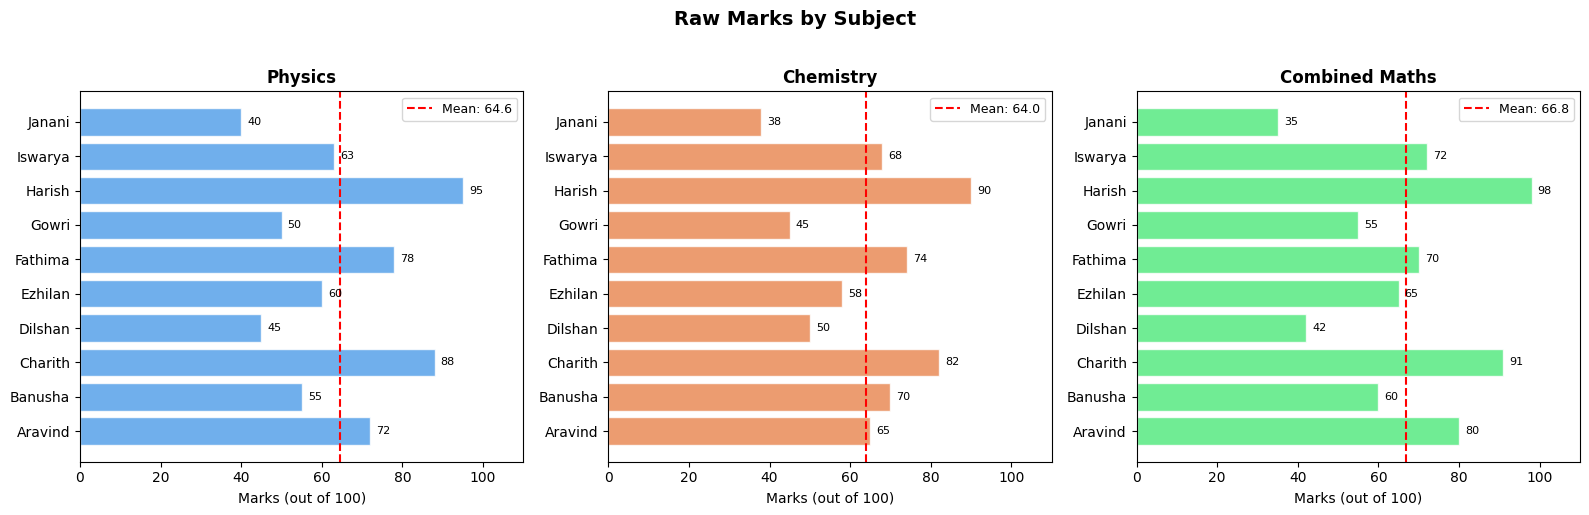

✅ Chart 1: Raw Marks saved as raw_marks.png


In [7]:
# ── Chart 1: Raw Marks Comparison ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Raw Marks by Subject', fontsize=14, fontweight='bold', y=1.02)

colors = ['#4C9BE8', '#E8834C', '#4CE87A']

for i, (subject, color) in enumerate(zip(subjects, colors)):
    ax = axes[i]
    vals = df_marks[subject]
    bars = ax.barh(students, vals, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(subject_mean[subject], color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {subject_mean[subject]:.1f}')
    ax.set_title(subject, fontweight='bold')
    ax.set_xlabel('Marks (out of 100)')
    ax.set_xlim(0, 110)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(val + 1.5, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('raw_marks.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1: Raw Marks saved as raw_marks.png')

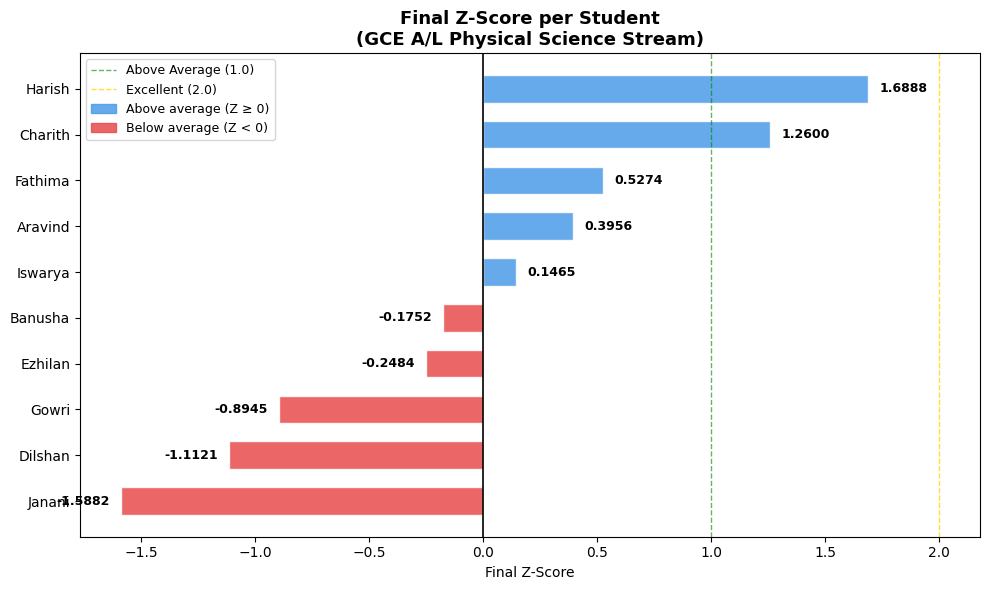

✅ Chart 2: Final Z-Scores saved as final_zscore.png


In [8]:
# ── Chart 2: Final Z-Score Bar Chart ───────────────────────────────
sorted_df = df_z.sort_values('Final Z-Score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#E84C4C' if z < 0 else '#4C9BE8' for z in sorted_df['Final Z-Score']]
bars = ax.barh(sorted_df.index, sorted_df['Final Z-Score'],
               color=bar_colors, alpha=0.85, edgecolor='white', height=0.6)

ax.axvline(0, color='black', linewidth=1.2, linestyle='-')
ax.axvline(1.0, color='green', linewidth=1, linestyle='--', alpha=0.6, label='Above Average (1.0)')
ax.axvline(2.0, color='gold', linewidth=1, linestyle='--', alpha=0.8, label='Excellent (2.0)')

for bar, val in zip(bars, sorted_df['Final Z-Score']):
    offset = 0.05 if val >= 0 else -0.05
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha=ha, fontsize=9, fontweight='bold')

ax.set_title('Final Z-Score per Student\n(GCE A/L Physical Science Stream)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Final Z-Score')
ax.legend(fontsize=9)

pos_patch = mpatches.Patch(color='#4C9BE8', alpha=0.85, label='Above average (Z ≥ 0)')
neg_patch = mpatches.Patch(color='#E84C4C', alpha=0.85, label='Below average (Z < 0)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [pos_patch, neg_patch], fontsize=9)

plt.tight_layout()
plt.savefig('final_zscore.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2: Final Z-Scores saved as final_zscore.png')

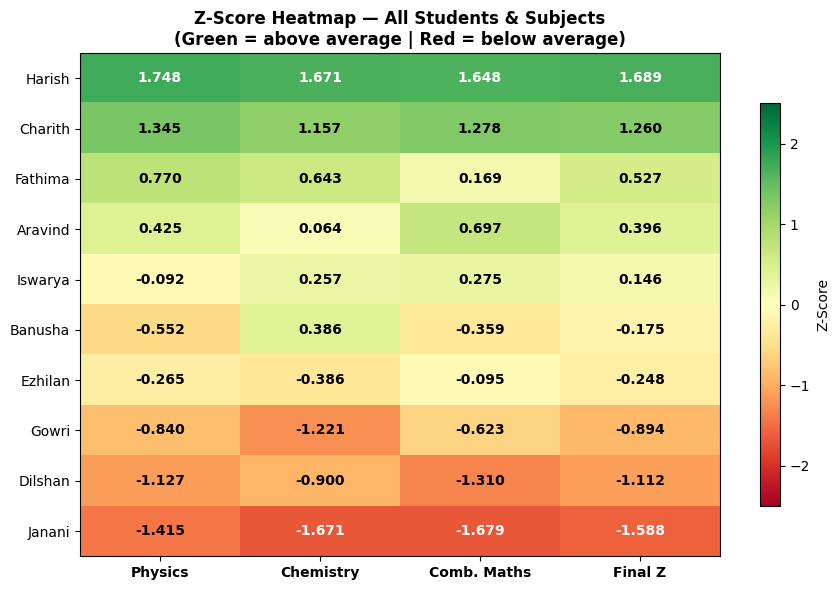

✅ Chart 3: Heatmap saved as zscore_heatmap.png


In [9]:
# ── Chart 3: Z-Score Heatmap ────────────────────────────────────────
import matplotlib.colors as mcolors

z_heat = df_z[['Z_Physics', 'Z_Chemistry', 'Z_Combined Maths', 'Final Z-Score']].copy()
z_heat.columns = ['Physics', 'Chemistry', 'Comb. Maths', 'Final Z']
z_heat = z_heat.sort_values('Final Z', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.RdYlGn
im = ax.imshow(z_heat.values, cmap=cmap, aspect='auto', vmin=-2.5, vmax=2.5)

ax.set_xticks(range(len(z_heat.columns)))
ax.set_xticklabels(z_heat.columns, fontweight='bold')
ax.set_yticks(range(len(z_heat.index)))
ax.set_yticklabels(z_heat.index)

for i in range(len(z_heat.index)):
    for j in range(len(z_heat.columns)):
        val = z_heat.values[i, j]
        text_color = 'white' if abs(val) > 1.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

plt.colorbar(im, ax=ax, label='Z-Score', shrink=0.8)
ax.set_title('Z-Score Heatmap — All Students & Subjects\n(Green = above average | Red = below average)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('zscore_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3: Heatmap saved as zscore_heatmap.png')

## Step 8 — Export Results to CSV

In [10]:
# Export full summary to CSV
export_df = df_summary.copy()
export_df.to_csv('al_zscore_results.csv')

print('✅ Results exported to al_zscore_results.csv')
print()
print('📁 Files generated in this session:')
print('   • al_zscore_results.csv  — full data table')
print('   • raw_marks.png          — raw marks chart')
print('   • final_zscore.png       — final Z-score bar chart')
print('   • zscore_heatmap.png     — heatmap of all Z-scores')
print()
print('─' * 60)
print('© Mohamed Nizzad | உள்ளத்திலிருந்து உள்ளத்திற்கு')
print('https://linkedin.com/in/mohamednizzad')
print('─' * 60)
print()
print('⚠️  DISCLAIMER: This notebook is purely for educational')
print('   purposes. Do not make any academic or admission')
print('   decisions based on this output. Refer to UGC Sri Lanka')
print('   (ugc.ac.lk) for official Z-score information.')

✅ Results exported to al_zscore_results.csv

📁 Files generated in this session:
   • al_zscore_results.csv  — full data table
   • raw_marks.png          — raw marks chart
   • final_zscore.png       — final Z-score bar chart
   • zscore_heatmap.png     — heatmap of all Z-scores

────────────────────────────────────────────────────────────
© Mohamed Nizzad | உள்ளத்திலிருந்து உள்ளத்திற்கு
https://linkedin.com/in/mohamednizzad
────────────────────────────────────────────────────────────

⚠️  DISCLAIMER: This notebook is purely for educational
   purposes. Do not make any academic or admission
   decisions based on this output. Refer to UGC Sri Lanka
   (ugc.ac.lk) for official Z-score information.
